<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 4

Para a viga de madeira ($E = 11$ GPa) e o carregamento indicados, determine:

a) A rotação nas extremidades A e D.

b) A posição e o valor da flecha máxima na viga.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au08/P4/MSII_Au08_P4.png"
style="max-width: 100%;"/>


In [13]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.b = .100  # unit: m
d.h = .150  # unit: m
d.LAB = 0.5  # unit: m
d.LBC = 0.5  # unit: m
d.LCD = 1.  # unit: m
d.PB = 10.e3 # unit: N
d.QCD = 5.e3 # unit: N/m
d.E = 11.e9 # unit: Pa

d.LAC = d.LAB + d.LBC
d.LBD = d.LBC + d.LCD
d.LAD = d.LAC + d.LCD

def irect(b,h): return b*h**3/12

I = irect(d.b,d.h)
print(f'I = {I:6.3e} m⁴')


I = 2.812e-05 m⁴


### Resumo: Equação da elástica

A expressão para a deflexão de uma viga, $y(x)$, descreve a localização do eixo da viga na posição deformada pela acção do carregamento imposto. Esta equação é conhecida como equação da linha elástica, e pode ser obtida na prática por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar nomeadamente as constantes de integração resultantes do processo matemática de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d}x²}
\quad\therefore\quad
y(x) \equiv v(x)
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d}x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, $M(x)$ - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.

### Resolução

- 1 ::: cálculo das reações

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M_D = 0
\end{equation*}

In [14]:
rax, ray, rdy = sy.symbols('rax ray rdy')

print('::: sistema de equações :::')
sumFX = rax
d.Qeq = d.QCD*d.LCD
print(f'd.Qeq = {d.Qeq} N')
sumFY = ray + rdy - d.PB - d.Qeq
print(f'sumFY = {sumFY} N')
sumMD = -ray*d.LAD + d.PB*d.LBD + d.Qeq*d.LCD/2
print(f'sumMD = {sumMD} N.m')
sol = solve([sumFX,sumFY,sumMD],[rax, ray, rdy])

print('::: resolução :::')
RAx = sol[rax]; print(f'RAx = {RAx} N')
RAy = sol[ray]; print(f'RAy = {RAy:.1f} N')
RDy = sol[rdy]; print(f'RDy = {RDy:.1f} N')

::: sistema de equações :::
d.Qeq = 5000.0 N
sumFY = ray + rdy - 15000.0 N
sumMD = 17500.0 - 2.0*ray N.m
::: resolução :::
RAx = 0.0 N
RAy = 8750.0 N
RDy = 6250.0 N


- 2 ::: Expressão do momento fletor escrita com base em funções de singularidade


As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Desenvolvendo,

\begin{equation*}
M(x) = R_{Ay} <x-0>^1 - P<x-0.5>^1 - \frac{Q}{2}<x-1>^2
+ \underbrace{R_{Dy} <x-L>^1}_{off}
\end{equation*}

- 3 ::: Equação da linha elástica:

\begin{equation*}
\frac{\partial² v(x)}{\partial x²} = \frac{M(x)}{EI}
\end{equation*}

por integração, obtem-se

\begin{equation*}
\theta(x) = \frac{\partial v(x)}{\partial x} = \left[
\frac{R_A}{2} x^2 - \frac{P}{2}<x-0.5>^2
- \frac{Q}{6}<x-1>^3 + C_1 \right] / EI
\end{equation*}

integrando novamente resulta

\begin{equation*}
v(x) = \left[
\frac{R_A}{6} x^3 - \frac{P}{6}<x-0.5>^3
- \frac{Q}{24}<x-1>^4 + C_1x + C_2 \right] / EI
\end{equation*}

As constantes de integração $C_1$ e $C_2$ são determinadas pelas condições de fronteira.

\begin{equation*}
\begin{aligned}
x = 0 \quad\Rightarrow\quad y(0) = 0
&\quad\therefore\quad C_2 = 0
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
&x = L \quad\Rightarrow\quad y(L) = 0
\quad\therefore\quad \\
& \frac{R_A}{6} L^3 - \frac{P}{6}(L-0.5)^3
- \frac{Q}{24}(L-1)^4 + C_1L = 0
\end{aligned}
\end{equation*}

In [15]:
c1, c2, x = sy.symbols('c1 c2 x')

print('::: eq. cond. fronteira :::')
def flex(x):
    return RAy/6*x**3 - d.PB/6*(x-d.LAB)**3 - d.QCD/24*(x-d.LAC)**4 + c1*x + c2

eqC2 = flex(0)
sol = solve(eqC2,c2)
C2 = sol[0]
print(f'C2 = {C2} [N.m]')

eqC1 = flex(d.LAD).subs(c2,C2)
sol = solve(eqC1,c1)
C1 = sol[0]
print(f'eqC1 = {printsymSF(eqC1)} | C1 = {C1:.2f} [N.m]')

::: eq. cond. fronteira :::
C2 = 0 [N.m]
eqC1 = 2.0*c1 + 5833.333 | C1 = -2916.67 [N.m]


In [16]:
def theta_(x):
    return sy.diff(flex(x).subs({(c1,C1),(c2,C2)}),x)/d.E/I

def y_(x):
    return flex(x).subs({(c1,C1),(c2,C2)})/d.E/I

print(f'1. theta(x) = ({printsymSF(theta_(x)*d.E*I)})/EI')
print(f'   theta(x) = {printsymSF(theta_(x))}')
eqtzer = theta_(x)
sol = solve(eqtzer,x)
r_ = [sol[0].args[0],sol[1].args[0],sol[2].args[0]]
print(f'2. Raizes da função (theta = 0) :: ({r_[0]:.3f},{r_[1]:.3f},{r_[2]:.3f})')
xmax = r_[1]
print(f'3. >>>> theta = 0 | xma = {xmax:.3f} m')

print('\n::: Deflexao maxima :::')
ymax = y_(xmax)
print(f'ymax({xmax:.3f}) = {ymax:.3e} m')


1. theta(x) = (-833.333*x**3 + 1875.0*x**2 + 2500.0*x - 3333.33333333333)/EI
   theta(x) = -0.00269360269360269*x**3 + 0.00606060606060606*x**2 + 0.00808080808080808*x - 0.0107744107744108
2. Raizes da função (theta = 0) :: (-1.506,0.945,2.811)
3. >>>> theta = 0 | xma = 0.945 m

::: Deflexao maxima :::
ymax(0.945) = -5.406e-3 m


In [17]:
print('\n::: Rotação A :::')
thetaA = theta_(x).subs(x,0.)
print(f'theta A ({0}) = {printsymSF(thetaA):.3e} [radianos]')

print('\n::: Rotação D :::')
thetaD = theta_(x).subs(x,d.LAD)
print(f'theta D ({d.LAD}) = {printsymSF(thetaD):.3e} [radianos]')


::: Rotação A :::
theta A (0) = -1.100e-2 [radianos]

::: Rotação D :::
theta D (2.0) = 8.000e-3 [radianos]


### Visualizção da flecha e rotação

- Tramo AB:

\begin{equation*}
v_{AB}(x) = \left[ \frac{R_A}{6} x^3 + C_1x \right] / EI
\end{equation*}

- Tramo BC:

\begin{equation*}
v_{BC}(x) = \left[
\frac{R_A}{6} x^3 - \frac{P}{6}<x-0.5>^3 + C_1x\right] / EI
\end{equation*}

- Tramo CD:

\begin{equation*}
v_{CD}(x) = \left[
\frac{R_A}{6} x^3 - \frac{P}{6}<x-0.5>^3
- \frac{Q}{24}<x-1>^4 + C_1x + C_2 \right] / EI
\end{equation*}

flexAB = 0.005*x**3 - 0.009*x
flexBC = 0.005*x**3 - 0.009*x - 0.005*(x - 0.5)**3
flexCD = 0.005*x**3 - 0.009*x - 0.e-3*(x - 1.0)**4 - 0.005*(x - 0.5)**3


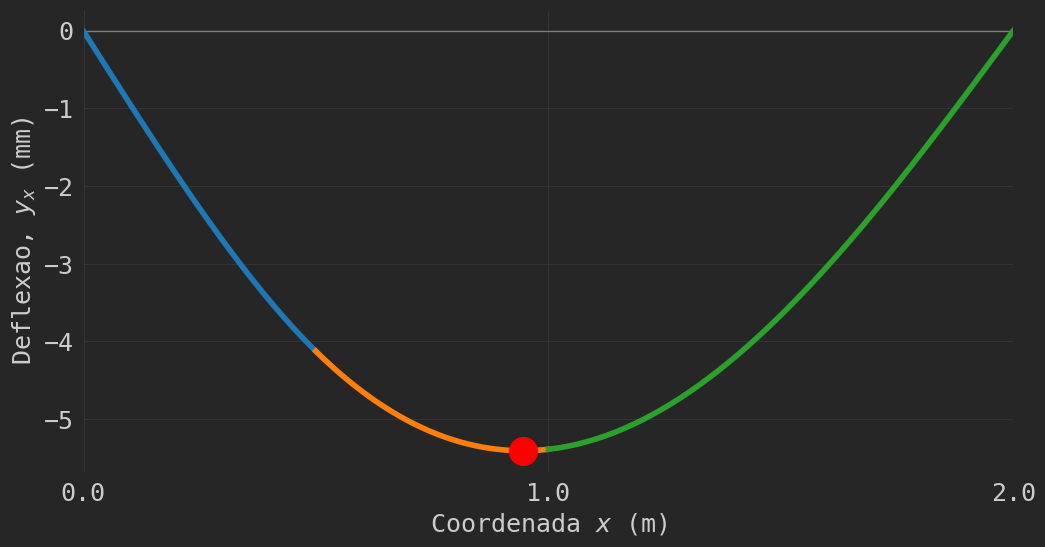

In [18]:
def printsymSF(expr):
    return expr.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

xAB = np.linspace(0,d.LAB)
xBC = np.linspace(d.LAB,d.LAC)
xCD = np.linspace(d.LAC,d.LAD)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

flexAB = lambda x: ( RAy/6*x**3 + C1*x + C2 )/d.E/I
flexBC = lambda x: ( RAy/6*x**3 - d.PB/6*(x-d.LAB)**3 + C1*x + C2 )/d.E/I
flexCD = lambda x: ( RAy/6*x**3 - d.PB/6*(x-d.LAB)**3 - d.QCD/24*(x-d.LAC)**4 + C1*x + C2 )/d.E/I

print(f'flexAB = {printsymSF(flexAB(x))}')
print(f'flexBC = {printsymSF(flexBC(x))}')
print(f'flexCD = {printsymSF(flexCD(x))}')

# AB
yflexAB = sy2array(flexAB(x)*1e3,xAB)
# BC
yflexBC = sy2array(flexBC(x)*1e3,xBC)
# CD
yflexCD = sy2array(flexCD(x)*1e3,xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yflexAB,linewidth=4)
plt.plot(xBC,yflexBC,linewidth=4)
plt.plot(xCD,yflexCD,linewidth=4)
plt.plot(xmax, ymax*1e3,'ro',markersize=20)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Deflexao, $y_{x}$ (mm)')
plt.xlim(0,2e-3)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.LAD*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

- Tramo AB:

\begin{equation*}
\theta(x) = \frac{\partial v}{\partial y} = \left[
\frac{R_A}{2} x^2 - \frac{P}{2}<x-0.5>^2
- \frac{Q}{6}<x-1>^3 + C_1 \right] / EI
\end{equation*}

- Tramo BC:

\begin{equation*}
\theta(x) = \frac{\partial v}{\partial y} = \left[
\frac{R_A}{2} x^2 - \frac{P}{2}<x-0.5>^2
- \frac{Q}{6}<x-1>^3 + C_1 \right] / EI
\end{equation*}

- Tramo CD:

\begin{equation*}
\theta(x) = \frac{\partial v}{\partial y} = \left[
\frac{R_A}{2} x^2 - \frac{P}{2}<x-0.5>^2
- \frac{Q}{6}<x-1>^3 + C_1 \right] / EI
\end{equation*}

rotAB = 0.014*x**2 - 0.009
rotBC = 0.014*x**2 - 0.016*(x - 0.5)**2 - 0.009
rotCD = 0.014*x**2 - 0.003*(x - 1.0)**3 - 0.016*(x - 0.5)**2 - 0.009


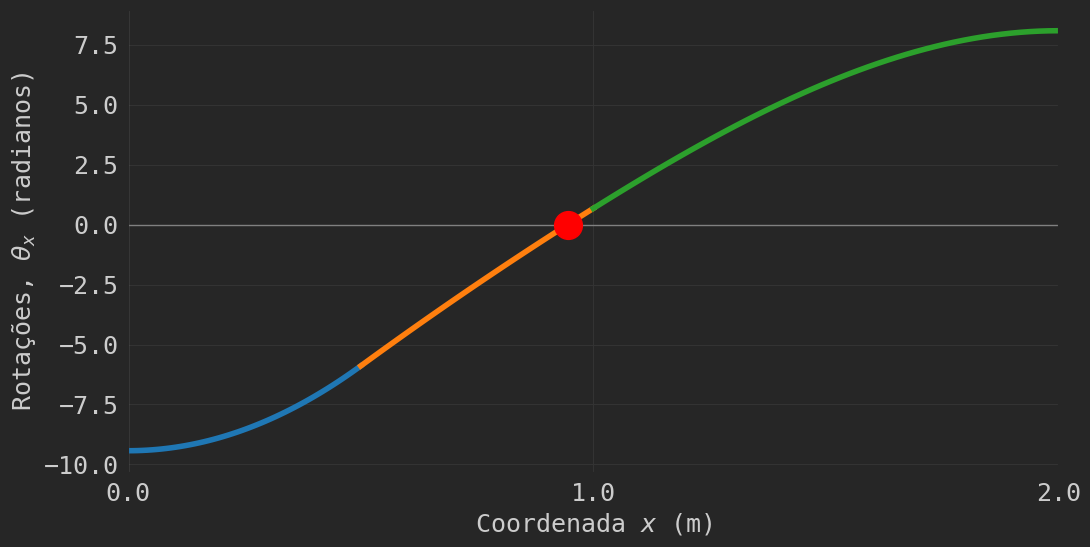

In [19]:

rotAB = lambda x: ( RAy/2*x**2 + C1)/d.E/I
rotBC = lambda x: ( RAy/2*x**2 - d.PB/2*(x-d.LAB)**2 + C1)/d.E/I
rotCD = lambda x: ( RAy/2*x**2 - d.PB/2*(x-d.LAB)**2 - d.QCD/6*(x-d.LAC)**3 + C1 )/d.E/I

print(f'rotAB = {printsymSF(rotAB(x))}')
print(f'rotBC = {printsymSF(rotBC(x))}')
print(f'rotCD = {printsymSF(rotCD(x))}')

# AB
protAB = sy2array(rotAB(x)*1e3,xAB)
# BC
protBC = sy2array(rotBC(x)*1e3,xBC)
# CD
protCD = sy2array(rotCD(x)*1e3,xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,protAB,linewidth=4)
plt.plot(xBC,protBC,linewidth=4)
plt.plot(xCD,protCD,linewidth=4)
plt.plot(xmax, 0,'ro',markersize=20)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Rotações, $\theta_{x}$ (radianos)')
plt.xlim(0,2e-3)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.LAD*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

### Anexo: Funções de singularidade

As funções de singularidade (ou funções de descontinuidade) são uma ferramenta matemática introduzida para representar, de forma compacta e sistemática, carregamentos e reações localizados (como forças e momentos concentrados, ou descontinuidades em vigas) nas equações diferenciais da linha elástica. Essas funções permitem escrever numa única expressão contínua a equação do momento fletor, da força cortante ou da deflexão, mesmo em situações com mudanças bruscas no carregamento.

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1} 
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e 

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/FuncoesSingularidade.png"
width="900">

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
